In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [7]:
df = pd.read_csv('/content/drive/MyDrive/Project/독버섯 탐지/mushrooms.csv')

X = df.drop(columns=['class'])
y = df['class']

X_encoded = pd.get_dummies(X, drop_first=True)

normal_mask = (y == 'e')
X_normal = X_encoded[normal_mask]
X_anomaly = X_encoded[~normal_mask]

X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)
X_test = pd.concat([X_test_normal, X_anomaly])
y_test = np.array([1] * len(X_test_normal) + [-1] * len(X_anomaly))

In [8]:
model = IsolationForest(n_estimators=150, contamination=0.01, random_state=42, n_jobs=-1)
model.fit(X_train)

IsolationForest(contamination=0.01, n_estimators=150, n_jobs=-1,
                random_state=42)

In [23]:
anomaly_scores = model.score_samples(X_test)

custom_threshold = np.percentile(anomaly_scores, 75)
y_pred = np.where(anomaly_scores < custom_threshold, -1, 1)

=== Isolation Forest 평가 리포트 ===
              precision    recall  f1-score   support

독버섯(Anomaly)       0.93      0.84      0.88      3916
식용버섯(Normal)       0.48      0.69      0.57       842

    accuracy                           0.82      4758
   macro avg       0.71      0.76      0.73      4758
weighted avg       0.85      0.82      0.83      4758

ROC-AUC Score: 0.8288


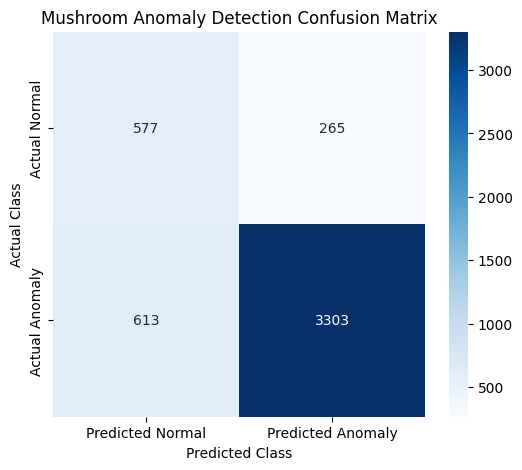

In [24]:
print("=== Isolation Forest 평가 리포트 ===")
print(classification_report(y_test, y_pred, target_names=['독버섯(Anomaly)', '식용버섯(Normal)']))

auc = roc_auc_score(y_test, anomaly_scores)
print(f"ROC-AUC Score: {auc:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=[1, -1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Mushroom Anomaly Detection Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()